In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path
import requests
from io import BytesIO
from zipfile import ZipFile, BadZipFile

import numpy as np
import pandas as pd
import pandas_datareader.data as web
from sklearn.datasets import fetch_openml

import requests
from io import StringIO

# pip install yfinance (설치되어 있지 않은 경우)
import yfinance as yf

pd.set_option('display.expand_frame_repr', False)

from itertools import product
from scipy.stats import spearmanr
import lightgbm as lgb
import zipfile

In [3]:
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd

# 1. 경로 설정
DATA_DIR = Path('../../data/data')
ZIP_PATH = DATA_DIR / 'd_jp_txt.zip'
HDF_PATH = DATA_DIR / 'japan.h5'

print(f"1) 로컬 압축 파일 확인: {ZIP_PATH.resolve()}")

dfs = []
print("2) 압축 파일에서 도쿄증권거래소(TSE) 2010~2019년 주가 데이터 추출 중...")

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    for filename in z.namelist():
        if filename.endswith('.txt') and any(k in filename for k in ['/d/', '/daily/']):
            try:
                ticker = Path(filename).name.split('.')[0]
                if not ticker.isalnum():
                    continue

                with z.open(filename) as f:
                    df = pd.read_csv(f)

                df.columns = [c.replace('<', '').replace('>', '').lower() for c in df.columns]

                if 'date' not in df.columns or 'close' not in df.columns or 'vol' not in df.columns:
                    continue

                df['date'] = pd.to_datetime(df['date'].astype(str), format='%Y%m%d', errors='coerce')
                df = df[(df['date'] >= '2010-01-01') & (df['date'] <= '2019-12-31')]
                if df.empty:
                    continue

                df['ticker'] = ticker
                dfs.append(df[['date', 'ticker', 'open', 'high', 'low', 'close', 'vol']])
            except Exception:
                continue

print(f"-> 총 {len(dfs)}개 종목 데이터 추출 완료. 병합 및 정렬 시작...")
data = pd.concat(dfs, ignore_index=True)
data = data.set_index(['date', 'ticker']).sort_index()

# 3. 유니버스 필터링
print("3) 유니버스 정제 중 (결측치 검사 및 거래대금 필터링)...")

# 거래 대금(종가 × 거래량) 계산
data['dollar_vol'] = data['close'] * data['vol']

# 3-1. 5일 이상 연속 결측치가 있는 종목 제거 (에러 수정된 안전한 로직)
all_dates = data.index.get_level_values('date').unique().sort_values()
close_pivot = data['close'].unstack('ticker').reindex(all_dates)

def get_max_consecutive_nans(series):
    is_nan = series.isna()
    # NaN이 아니면 그룹 번호가 증가하여 연속된 NaN끼리 동일 그룹으로 묶임
    nan_groups = (~is_nan).cumsum()
    return is_nan.groupby(nan_groups).sum().max()

# 종목별 최대 연속 결측일 계산 (5일 미만만 통과)
max_nans_per_ticker = close_pivot.apply(get_max_consecutive_nans)
valid_tickers_no_gaps = max_nans_per_ticker[max_nans_per_ticker < 5].index

data = data[data.index.get_level_values('ticker').isin(valid_tickers_no_gaps)]

# 3-2. 전체 기간(2010~2019) 평균 거래 대금 상위 1,000개 선별
top_1000_tickers = (
    data.groupby('ticker')['dollar_vol']
    .mean()
    .nlargest(1000)
    .index
)
data_1000 = data[data.index.get_level_values('ticker').isin(top_1000_tickers)]

# 3-3. 2010~2017년 기간 평균 거래 대금 상위 250개 종목 압축
in_sample_mask = (data_1000.index.get_level_values('date') >= '2010-01-01') & \
                 (data_1000.index.get_level_values('date') <= '2017-12-31')

top_250_tickers = (
    data_1000[in_sample_mask]
    .groupby('ticker')['dollar_vol']
    .mean()
    .nlargest(250)
    .index
)
final_data = data_1000[data_1000.index.get_level_values('ticker').isin(top_250_tickers)]

# 4. 기간 분할 (In-Sample / Out-of-Sample)
in_sample = final_data[final_data.index.get_level_values('date') <= '2017-12-31']
out_of_sample = final_data[final_data.index.get_level_values('date') >= '2018-01-01']

# 5. japan.h5 저장
print(f"4) 최종 데이터 저장 중 -> {HDF_PATH}...")
with pd.HDFStore(HDF_PATH, mode='w') as store:
    store.put('equities/japan/prices_250', final_data, format='table')
    store.put('equities/japan/in_sample', in_sample, format='table')
    store.put('equities/japan/out_sample', out_of_sample, format='table')

print(f" 정제 및 저장 완료! (최종 유니버스: {len(top_250_tickers)}개 종목)")

1) 로컬 압축 파일 확인: G:\내 드라이브\03.졸업논문\ml4t_pipeline\data\data\d_jp_txt.zip
2) 압축 파일에서 도쿄증권거래소(TSE) 2010~2019년 주가 데이터 추출 중...


-> 총 3398개 종목 데이터 추출 완료. 병합 및 정렬 시작...
3) 유니버스 정제 중 (결측치 검사 및 거래대금 필터링)...
4) 최종 데이터 저장 중 -> ..\..\data\data\japan.h5...
 정제 및 저장 완료! (최종 유니버스: 250개 종목)


In [4]:
# -------------------------------------------------------------
# [2단계] 특성 공학(18개 Feature) 및 예측 타깃(4개 Forward Returns) 생성
# -------------------------------------------------------------
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path('../../data/data')
HDF_PATH = DATA_DIR / 'japan.h5'

print("1) 기본 주가 데이터 로드 중...")
with pd.HDFStore(HDF_PATH, mode='r') as store:
    prices = store['equities/japan/prices_250']

print("2) 18개 특성 및 4개 타깃 변수 생성 중...")

def calc_stock_features(df):
    df = df.sort_index()
    c, h, l, v = df['close'], df['high'], df['low'], df['vol']
    feats = pd.DataFrame(index=df.index)
    
    # 1. 과거 시차 누적 수익률 (1, 5, 10, 21, 63 거래일)
    for lag in [1, 5, 10, 21, 63]:
        feats[f'ret_{lag}'] = c.pct_change(lag)
        
    # 2. 기술적 지표 계산
    # PPO (12, 26일 EMA 기반 백분율 모멘텀)
    ema12 = c.ewm(span=12, adjust=False).mean()
    ema26 = c.ewm(span=26, adjust=False).mean()
    feats['ppo'] = ((ema12 - ema26) / (ema26 + 1e-9)) * 100
    
    # NATR (14일 정규화 변동성)
    tr1 = h - l
    tr2 = (h - c.shift(1)).abs()
    tr3 = (l - c.shift(1)).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(14).mean()
    feats['natr'] = (atr / (c + 1e-9)) * 100
    
    # RSI (14일 상대강도지수)
    delta = c.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.rolling(14).mean()
    roll_down = down.rolling(14).mean()
    rs = roll_up / (roll_down + 1e-9)
    feats['rsi'] = 100.0 - (100.0 / (1.0 + rs))
    
    # Bollinger Bands 이격도 (20일 기준)
    mid = c.rolling(20).mean()
    std = c.rolling(20).std()
    upper = mid + (2 * std)
    lower = mid - (2 * std)
    feats['bb_percent'] = (c - lower) / (upper - lower + 1e-9)
    
    # 3. 예측 타깃 (Forward Returns: 1, 5, 10, 21일 후 수익률)
    for fwd in [1, 5, 10, 21]:
        feats[f'target_{fwd}d'] = c.pct_change(fwd).shift(-fwd)
        
    return feats

# 종목별 지표 계산
features = prices.groupby('ticker', group_keys=False).apply(calc_stock_features)

# 4. 단면 순위 및 달력 범주형 변수
print("3) 단면 순위 및 달력 범주형 변수 생성 중...")
# transform 사용: 최신 pandas에서 apply가 MultiIndex 레벨을 추가로 붙이는 문제 방지
# (동일 인덱스 형태를 보장하는 transform이 qcut 단면 순위 계산에 더 안전함)
features['ret_1_rank'] = features.groupby('date')['ret_1'].transform(
    lambda x: pd.qcut(x, q=20, labels=False, duplicates='drop')
)

dates = features.index.get_level_values('date')
features['day_of_week'] = dates.dayofweek
features['month'] = dates.month
features['year'] = dates.year

# 윈도우 계산 초기 결측치 및 미래 타깃 끝단 결측치 제거
clean_data = features.dropna()

print(f"4) 'equities/japan/features_targets'로 HDF5 저장 중 (크기: {clean_data.shape})...")
with pd.HDFStore(HDF_PATH, mode='a') as store:
    store.put('equities/japan/features_targets', clean_data, format='table')

print("✅ 특성 및 타깃 저장 완료!")

1) 기본 주가 데이터 로드 중...
2) 18개 특성 및 4개 타깃 변수 생성 중...
3) 단면 순위 및 달력 범주형 변수 생성 중...
4) 'equities/japan/features_targets'로 HDF5 저장 중 (크기: (590755, 17))...
✅ 특성 및 타깃 저장 완료!


In [5]:
# 1. 데이터 로드
DATA_DIR = Path('../../data/data')
HDF_PATH = DATA_DIR / 'japan.h5'

print("1) 정제 데이터 로드 중...")
with pd.HDFStore(HDF_PATH, mode='r') as store:
    # 2단계에서 생성한 피처/타깃 데이터셋 로드
    df = store['equities/japan/features_targets']

# In-Sample 기간 (2010 ~ 2017) 데이터 필터링
dates = df.index.get_level_values('date')
in_sample = df[(dates >= '2010-01-01') & (dates <= '2017-12-31')].sort_index()

# 특성(X) 및 범주형 변수 설정
target_cols = [c for c in in_sample.columns if c.startswith('target_')]
feature_cols = [c for c in in_sample.columns if not c.startswith('target_')]
categorical_cols = ['ret_1_rank', 'day_of_week', 'month', 'year']

# LightGBM용 범주형 변수 타입 변환
for cat in categorical_cols:
    if cat in in_sample.columns:
        in_sample[cat] = in_sample[cat].astype('category')

1) 정제 데이터 로드 중...


In [6]:
# 2. MultipleTimeSeriesCV 클래스 정의 (Lookahead Gap 적용)
class MultipleTimeSeriesCV:
    """
    Rolling/Expanding 윈도우 기반 시계열 교차 검증 생성기
    - n_splits: 폴드 수
    - train_period_length: 학습 일수 (예: 504일, 1260일)
    - test_period_length: 예측 일수 (예: 21일, 63일)
    - lookahead: 타깃 horizon 간격 (Lookahead Bias 방지용 Gap)
    """
    def __init__(self, n_splits=5, train_period_length=1260, test_period_length=63, lookahead=1):
        self.n_splits = n_splits
        self.train_period_length = train_period_length
        self.test_period_length = test_period_length
        self.lookahead = lookahead

    def split(self, X, y=None, groups=None):
        unique_dates = X.index.get_level_values('date').unique().sort_values()
        n_dates = len(unique_dates)
        total_period = self.train_period_length + self.lookahead + self.test_period_length
        
        if n_dates < total_period:
            raise ValueError(f"전체 거래일({n_dates}일)이 CV 요구 기간({total_period}일)보다 적습니다.")
            
        step = (n_dates - total_period) // (self.n_splits - 1) if self.n_splits > 1 else 0
        
        for i in range(self.n_splits):
            train_start_idx = i * step
            train_end_idx = train_start_idx + self.train_period_length
            
            # 룩어헤드 간격(Lookahead Gap) 만큼 건너뜀 (정보 누수 방지)
            test_start_idx = train_end_idx + self.lookahead
            test_end_idx = test_start_idx + self.test_period_length
            
            train_dates = unique_dates[train_start_idx:train_end_idx]
            test_dates = unique_dates[test_start_idx:test_end_idx]
            
            train_mask = X.index.get_level_values('date').isin(train_dates)
            test_mask = X.index.get_level_values('date').isin(test_dates)
            
            yield np.where(train_mask)[0], np.where(test_mask)[0]


In [7]:
# 3. 하이퍼파라미터 그리드 구성
base_params = dict(
    boosting_type='rf',
    objective='regression',
    bagging_freq=1,
    verbose=-1,
    n_jobs=-1
)

bagging_fraction_opts = [.5, .75, .95]
feature_fraction_opts = [.75, .95]
min_data_in_leaf_opts = [250, 500, 1000]

cv_params = list(product(bagging_fraction_opts, feature_fraction_opts, min_data_in_leaf_opts))
n_cv_params = len(cv_params)

print(f"총 하이퍼파라미터 조합 수: {n_cv_params}개")

총 하이퍼파라미터 조합 수: 18개


In [8]:
# 4. 일별 IC(Information Coefficient) 계산 함수
def compute_daily_ic(df_pred):
    """일별 실제 수익률과 예측값 사이의 스피어만 상관계수(IC) 평균 계산"""
    def calc_ic(group):
        if len(group) < 5 or group['pred'].nunique() <= 1:
            return np.nan
        return spearmanr(group['target'], group['pred'])[0]
        
    daily_ic = df_pred.groupby('date').apply(calc_ic)
    return daily_ic.mean()


In [9]:
# -------------------------------------------------------------------
# 5. 교차 검증 실행 (Scikit-Learn Random Forest 안정 버전)
# -------------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor

target = 'target_1d'

# 1. 데이터 및 타깃 분리
df_clean = in_sample.copy()

# 범주형 컬럼 정수 인코딩
for col in categorical_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category').cat.codes.astype('int32')

dates_arr = df_clean.index.get_level_values('date')
X_all = df_clean[feature_cols].copy()
y_all = df_clean[target].copy()

cv = MultipleTimeSeriesCV(
    n_splits=5,
    train_period_length=504,
    test_period_length=63,
    lookahead=1
)

results = []
print(f"2) Random Forest 교차 검증 시작 (Target: {target})...")

for param_idx, (bf, ff, mdl) in enumerate(cv_params, 1):
    fold_ics = []
    
    # Scikit-Learn의 RandomForestRegressor 매핑
    # bagging_fraction -> max_samples
    # feature_fraction -> max_features
    # min_data_in_leaf -> min_samples_leaf
    model = RandomForestRegressor(
        n_estimators=100,
        max_samples=bf,
        max_features=ff,
        min_samples_leaf=mdl,
        random_state=42,
        n_jobs=-1  # Scikit-Learn은 멀티코어 충돌 없이 초고속 동작
    )
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_all)):
        X_train, y_train = X_all.iloc[train_idx], y_all.iloc[train_idx]
        X_val, y_val = X_all.iloc[val_idx], y_all.iloc[val_idx]
        
        # 모델 학습
        model.fit(X_train, y_train)
        
        # 검증셋 예측 및 일별 IC 산출
        val_preds = model.predict(X_val)
        val_df = pd.DataFrame({
            'date': dates_arr[val_idx],
            'target': y_val.values,
            'pred': val_preds
        })
        
        ic = compute_daily_ic(val_df)
        fold_ics.append(ic)
        
    mean_ic = np.nanmean(fold_ics)
    results.append({
        'bagging_fraction': bf,
        'feature_fraction': ff,
        'min_data_in_leaf': mdl,
        'mean_ic': mean_ic,
        'ic_std': np.nanstd(fold_ics)
    })
    
    print(f"[{param_idx:02d}/{n_cv_params}] bf={bf}, ff={ff}, min_leaf={mdl} -> Mean IC: {mean_ic:.4f}")

2) Random Forest 교차 검증 시작 (Target: target_1d)...
[01/18] bf=0.5, ff=0.75, min_leaf=250 -> Mean IC: 0.0037
[02/18] bf=0.5, ff=0.75, min_leaf=500 -> Mean IC: 0.0012
[03/18] bf=0.5, ff=0.75, min_leaf=1000 -> Mean IC: -0.0033
[04/18] bf=0.5, ff=0.95, min_leaf=250 -> Mean IC: 0.0071
[05/18] bf=0.5, ff=0.95, min_leaf=500 -> Mean IC: 0.0019
[06/18] bf=0.5, ff=0.95, min_leaf=1000 -> Mean IC: -0.0038
[07/18] bf=0.75, ff=0.75, min_leaf=250 -> Mean IC: 0.0051
[08/18] bf=0.75, ff=0.75, min_leaf=500 -> Mean IC: 0.0039
[09/18] bf=0.75, ff=0.75, min_leaf=1000 -> Mean IC: -0.0017
[10/18] bf=0.75, ff=0.95, min_leaf=250 -> Mean IC: 0.0126
[11/18] bf=0.75, ff=0.95, min_leaf=500 -> Mean IC: 0.0064
[12/18] bf=0.75, ff=0.95, min_leaf=1000 -> Mean IC: -0.0028
[13/18] bf=0.95, ff=0.75, min_leaf=250 -> Mean IC: 0.0092
[14/18] bf=0.95, ff=0.75, min_leaf=500 -> Mean IC: 0.0059
[15/18] bf=0.95, ff=0.75, min_leaf=1000 -> Mean IC: -0.0030
[16/18] bf=0.95, ff=0.95, min_leaf=250 -> Mean IC: 0.0086
[17/18] bf=0.95, ff

In [10]:
# 6. 결과 정리 및 최적 조합 도출
res_df = pd.DataFrame(results).sort_values(by='mean_ic', ascending=False)
print("\n" + "="*50)
print(" 교차 검증 상위 5개 하이퍼파라미터 조합:")
print("="*50)
print(res_df.head())


 교차 검증 상위 5개 하이퍼파라미터 조합:
    bagging_fraction  feature_fraction  min_data_in_leaf   mean_ic    ic_std
9               0.75              0.95               250  0.012613  0.011978
12              0.95              0.75               250  0.009199  0.012417
15              0.95              0.95               250  0.008611  0.014308
16              0.95              0.95               500  0.008000  0.006639
3               0.50              0.95               250  0.007072  0.013678


In [11]:
# 7. 검증 결과 HDF5 저장
with pd.HDFStore(HDF_PATH, mode='a') as store:
    store.put('model/rf_tuning_results', res_df, format='table')
print(f"\n결과가 {HDF_PATH}의 'model/rf_tuning_results'에 저장되었습니다.")


결과가 ..\..\data\data\japan.h5의 'model/rf_tuning_results'에 저장되었습니다.


In [12]:
# 8. 최적 하이퍼파라미터로 표본 외(Out-of-Sample, 2018~2019) 최종 평가
best_params = res_df.iloc[0]
print(f"최적 하이퍼파라미터 적용: bf={best_params['bagging_fraction']}, ff={best_params['feature_fraction']}, min_leaf={int(best_params['min_data_in_leaf'])}")

최적 하이퍼파라미터 적용: bf=0.75, ff=0.95, min_leaf=250


In [13]:
# 인샘플 전체로 최종 모델 학습
final_model = RandomForestRegressor(
    n_estimators=100,
    max_samples=best_params['bagging_fraction'],
    max_features=best_params['feature_fraction'],
    min_samples_leaf=int(best_params['min_data_in_leaf']),
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_all, y_all)

RandomForestRegressor(max_features=0.95, max_samples=0.75, min_samples_leaf=250,
                      n_jobs=-1, random_state=42)

In [14]:
# Out-of-Sample 데이터 로드 및 정제
with pd.HDFStore(HDF_PATH, mode='r') as store:
    full_df = store['equities/japan/features_targets']

oos_dates = full_df.index.get_level_values('date')
oos_df = full_df[(oos_dates >= '2018-01-01') & (oos_dates <= '2019-12-31')].sort_index()

In [15]:
# 범주형 컬럼 정수 인코딩
for col in categorical_cols:
    if col in oos_df.columns:
        oos_df[col] = oos_df[col].astype('category').cat.codes.astype('int32')

X_oos = oos_df[feature_cols]
y_oos = oos_df[target]

In [16]:
# 예측 수행
oos_preds = final_model.predict(X_oos)
oos_eval_df = pd.DataFrame({
    'date': oos_df.index.get_level_values('date'),
    'target': y_oos.values,
    'pred': oos_preds
})

In [17]:
# Out-of-Sample IC 계산
oos_ic = compute_daily_ic(oos_eval_df)
print("="*50)
print(f"✅ 표본 외(Out-of-Sample, 2018~2019) 평균 Daily IC: {oos_ic:.4f}")
print("="*50)

✅ 표본 외(Out-of-Sample, 2018~2019) 평균 Daily IC: 0.0014


In [18]:
# 최종 예측값 저장
with pd.HDFStore(HDF_PATH, mode='a') as store:
    store.put('model/oos_predictions', oos_eval_df, format='table')
print(f"Out-of-Sample 예측 결과가 {HDF_PATH}의 'model/oos_predictions'에 저장되었습니다.")

Out-of-Sample 예측 결과가 ..\..\data\data\japan.h5의 'model/oos_predictions'에 저장되었습니다.


## [3단계] 다중 호라이즌(1·5·10·21일) 예측 모델 확장 및 백테스팅

앞서 학습한 Random Forest 모델은 `target_1d`(익일 수익률) 하나만 예측했습니다. 이제 동일한 특성(feature)과 In-Sample/Out-of-Sample 분할을 그대로 사용하되, 예측 타깃을 `target_1d`, `target_5d`, `target_10d`, `target_21d` 네 가지로 확장합니다.

**설계상의 단순화**: 4개 타깃 각각에 대해 18개 조합 × 5-Fold 그리드서치를 다시 수행하면 연산 비용이 4배로 늘어나므로, `target_1d`에서 이미 탐색한 최적 하이퍼파라미터(`best_params`)를 그대로 재사용해 4개의 최종 모델을 각각 학습합니다.

이후 각 호라이즌 모델의 Out-of-Sample(2018~2019) 예측치를 신호로 사용해
- **Backtrader**와 **Zipline** 두 엔진으로 동일한 롱숏(Long-Short) 전략을 백테스트하고,
- 매매 비용은 **체결 1회당 고정 $0.02**, **슬리피지 없음**으로 두 엔진에 동일하게 적용하며,
- 모든 백테스트 결과는 **니케이225(Nikkei 225) 지수**와 비교하여 시각화합니다.

In [19]:
# 1. 4개 호라이즌(1/5/10/21일) 최종 모델 학습 및 OOS 예측
# -------------------------------------------------------------------------------
# [수정] target_h는 h거래일 뒤 수익률이므로, in_sample 마지막 h거래일의 라벨은
# 실제로는 2018년 OOS 구간의 가격까지 사용해 계산된 값입니다(IS/OOS 경계를 넘는 정보 누수).
# 이를 막기 위해 호라이즌 h만큼 in_sample 뒷부분을 embargo(제외)하고 학습합니다.
# -------------------------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
import joblib

OUTPUT_DIR = Path('.')

HORIZONS = [1, 5, 10, 21]
models_by_horizon = {}
oos_preds_by_horizon = {}
oos_ic_by_horizon = {}

in_sample_dates = np.sort(df_clean.index.get_level_values('date').unique())
in_sample_date_level = df_clean.index.get_level_values('date')

print("호라이즌별 최종 모델 학습 시작 (공통 하이퍼파라미터 재사용, 호라이즌별 embargo 적용)...")
for h in HORIZONS:
    tgt_col = f'target_{h}d'

    # embargo: in_sample 마지막 h거래일 제외 (그 라벨들은 2018년 OOS 가격을 사용해 계산되었기 때문)
    cutoff_date = in_sample_dates[-h]
    train_mask = in_sample_date_level < cutoff_date
    n_embargoed = (~train_mask).sum()

    X_all_h = X_all[train_mask]
    y_all_h = df_clean.loc[train_mask, tgt_col].copy()
    y_oos_h = oos_df[tgt_col].copy()

    model_h = RandomForestRegressor(
        n_estimators=100,
        max_samples=best_params['bagging_fraction'],
        max_features=best_params['feature_fraction'],
        min_samples_leaf=int(best_params['min_data_in_leaf']),
        random_state=42,
        n_jobs=-1
    )
    model_h.fit(X_all_h, y_all_h)
    models_by_horizon[h] = model_h

    preds_h = model_h.predict(X_oos)
    eval_df_h = pd.DataFrame({
        'date': oos_df.index.get_level_values('date'),
        'ticker': oos_df.index.get_level_values('ticker'),
        'target': y_oos_h.values,
        'pred': preds_h
    })
    oos_preds_by_horizon[h] = eval_df_h
    oos_ic_by_horizon[h] = compute_daily_ic(eval_df_h)

    joblib.dump(model_h, OUTPUT_DIR / f'final_rf_model_{h}d.joblib')
    with pd.HDFStore(HDF_PATH, mode='a') as store:
        store.put(f'model/oos_predictions_{h}d', eval_df_h, format='table')

    print(f"  [target_{h}d] embargo {n_embargoed}건 제외, 학습 {len(X_all_h):,}건 -> "
          f"OOS 평균 Daily IC: {oos_ic_by_horizon[h]:.4f}")

ic_summary = pd.DataFrame({
    '호라이즌(일)': HORIZONS,
    'OOS 평균 Daily IC': [oos_ic_by_horizon[h] for h in HORIZONS]
})
print("\n" + "=" * 50)
print(" 호라이즌별 Out-of-Sample IC 요약")
print("=" * 50)
print(ic_summary.to_string(index=False))

호라이즌별 최종 모델 학습 시작 (공통 하이퍼파라미터 재사용, 호라이즌별 embargo 적용)...
  [target_1d] embargo 250건 제외, 학습 474,255건 -> OOS 평균 Daily IC: 0.0011
  [target_5d] embargo 1250건 제외, 학습 473,255건 -> OOS 평균 Daily IC: 0.0116
  [target_10d] embargo 2500건 제외, 학습 472,005건 -> OOS 평균 Daily IC: 0.0013
  [target_21d] embargo 5250건 제외, 학습 469,255건 -> OOS 평균 Daily IC: -0.0023

 호라이즌별 Out-of-Sample IC 요약
 호라이즌(일)  OOS 평균 Daily IC
       1         0.001100
       5         0.011569
      10         0.001265
      21        -0.002317


In [20]:
# 2. 모델 요약 정보 출력 (sklearn 트리 앙상블용 model.summary() 대응)
# scikit-learn의 RandomForestRegressor에는 Keras의 model.summary()와 동일한 API가 없으므로,
# 하이퍼파라미터·트리 구조 통계·특성 중요도를 포함한 유사한 형태의 요약을 직접 출력합니다.
def print_rf_summary(model, horizon, feature_cols):
    n_trees = len(model.estimators_)
    total_nodes = sum(est.tree_.node_count for est in model.estimators_)
    total_leaves = sum(est.get_n_leaves() for est in model.estimators_)
    avg_depth = np.mean([est.get_depth() for est in model.estimators_])

    print("=" * 70)
    print(f" Model Summary : RandomForestRegressor  (target_{horizon}d)")
    print("=" * 70)
    print(f"{'Hyperparameter':<30}{'Value':>15}")
    print("-" * 70)
    print(f"{'n_estimators (트리 수)':<30}{n_trees:>15}")
    print(f"{'max_samples (bagging_fraction)':<30}{model.max_samples:>15}")
    print(f"{'max_features (feature_fraction)':<30}{model.max_features:>15}")
    print(f"{'min_samples_leaf':<30}{model.min_samples_leaf:>15}")
    print(f"{'입력 특성 수':<30}{len(feature_cols):>15}")
    print(f"{'총 노드 수 (전체 트리 합)':<30}{total_nodes:>15,}")
    print(f"{'총 리프 수 (전체 트리 합)':<30}{total_leaves:>15,}")
    print(f"{'평균 트리 깊이':<30}{avg_depth:>15.2f}")
    print("-" * 70)

    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print(" Top 10 Feature Importances:")
    for feat, imp in importances.head(10).items():
        bar = '#' * max(1, int(imp * 100))
        print(f"   {feat:<15} {imp:.4f}  {bar}")
    print("=" * 70 + "\n")
    return importances

feature_importances_by_horizon = {}
for h in HORIZONS:
    feature_importances_by_horizon[h] = print_rf_summary(models_by_horizon[h], h, feature_cols)

 Model Summary : RandomForestRegressor  (target_1d)
Hyperparameter                          Value
----------------------------------------------------------------------
n_estimators (트리 수)                       100
max_samples (bagging_fraction)           0.75
max_features (feature_fraction)           0.95
min_samples_leaf                          250
입력 특성 수                                    13
총 노드 수 (전체 트리 합)                      152,610
총 리프 수 (전체 트리 합)                       76,355
평균 트리 깊이                                25.86
----------------------------------------------------------------------
 Top 10 Feature Importances:
   month           0.1904  ###################
   day_of_week     0.1541  ###############
   year            0.1280  ############
   ret_5           0.1083  ##########
   ret_1           0.0995  #########
   natr            0.0624  ######
   ret_10          0.0579  #####
   bb_percent      0.0403  ####
   rsi             0.0392  ###
   ret_21          0.0391  

### 모델 트리 구조 시각화 (Decision Tree)

Random Forest는 100개의 개별 트리(estimator)로 구성된 앙상블 모델입니다. "이 모델이 실제로 어떤 기준으로 데이터를 나누는가"를 직접 보기 위해, 각 호라이즌 최종 모델의 **첫 번째 트리(`estimators_[0]`)**를 시각화합니다.

- 트리 전체는 평균 깊이가 25단계가 넘어(`min_samples_leaf=250`으로도 상당히 깊음) 그대로 그리면 수천 개 노드가 겹쳐 읽을 수 없으므로, **상위 3단계까지만 잘라서(`max_depth=3`)** 표시합니다.
- 각 노드에는 분기 기준(어떤 피처를 어떤 값 기준으로 나누는지), 그 노드에 속한 표본 수(samples), 그 노드의 평균 예측값(value)이 표시됩니다.
- 100개 트리 중 1개(#0)만 보여주는 것이므로, 실제 모델의 최종 예측은 이런 트리 100개의 평균이라는 점에 유의해서 "이 모델이 대체로 어떤 식으로 갈라지는가"에 대한 예시로 참고합니다.

모델 트리 구조 그래프 저장 위치: G:\내 드라이브\03.졸업논문\ml4t_pipeline\model\11단원\model_tree_plot.png


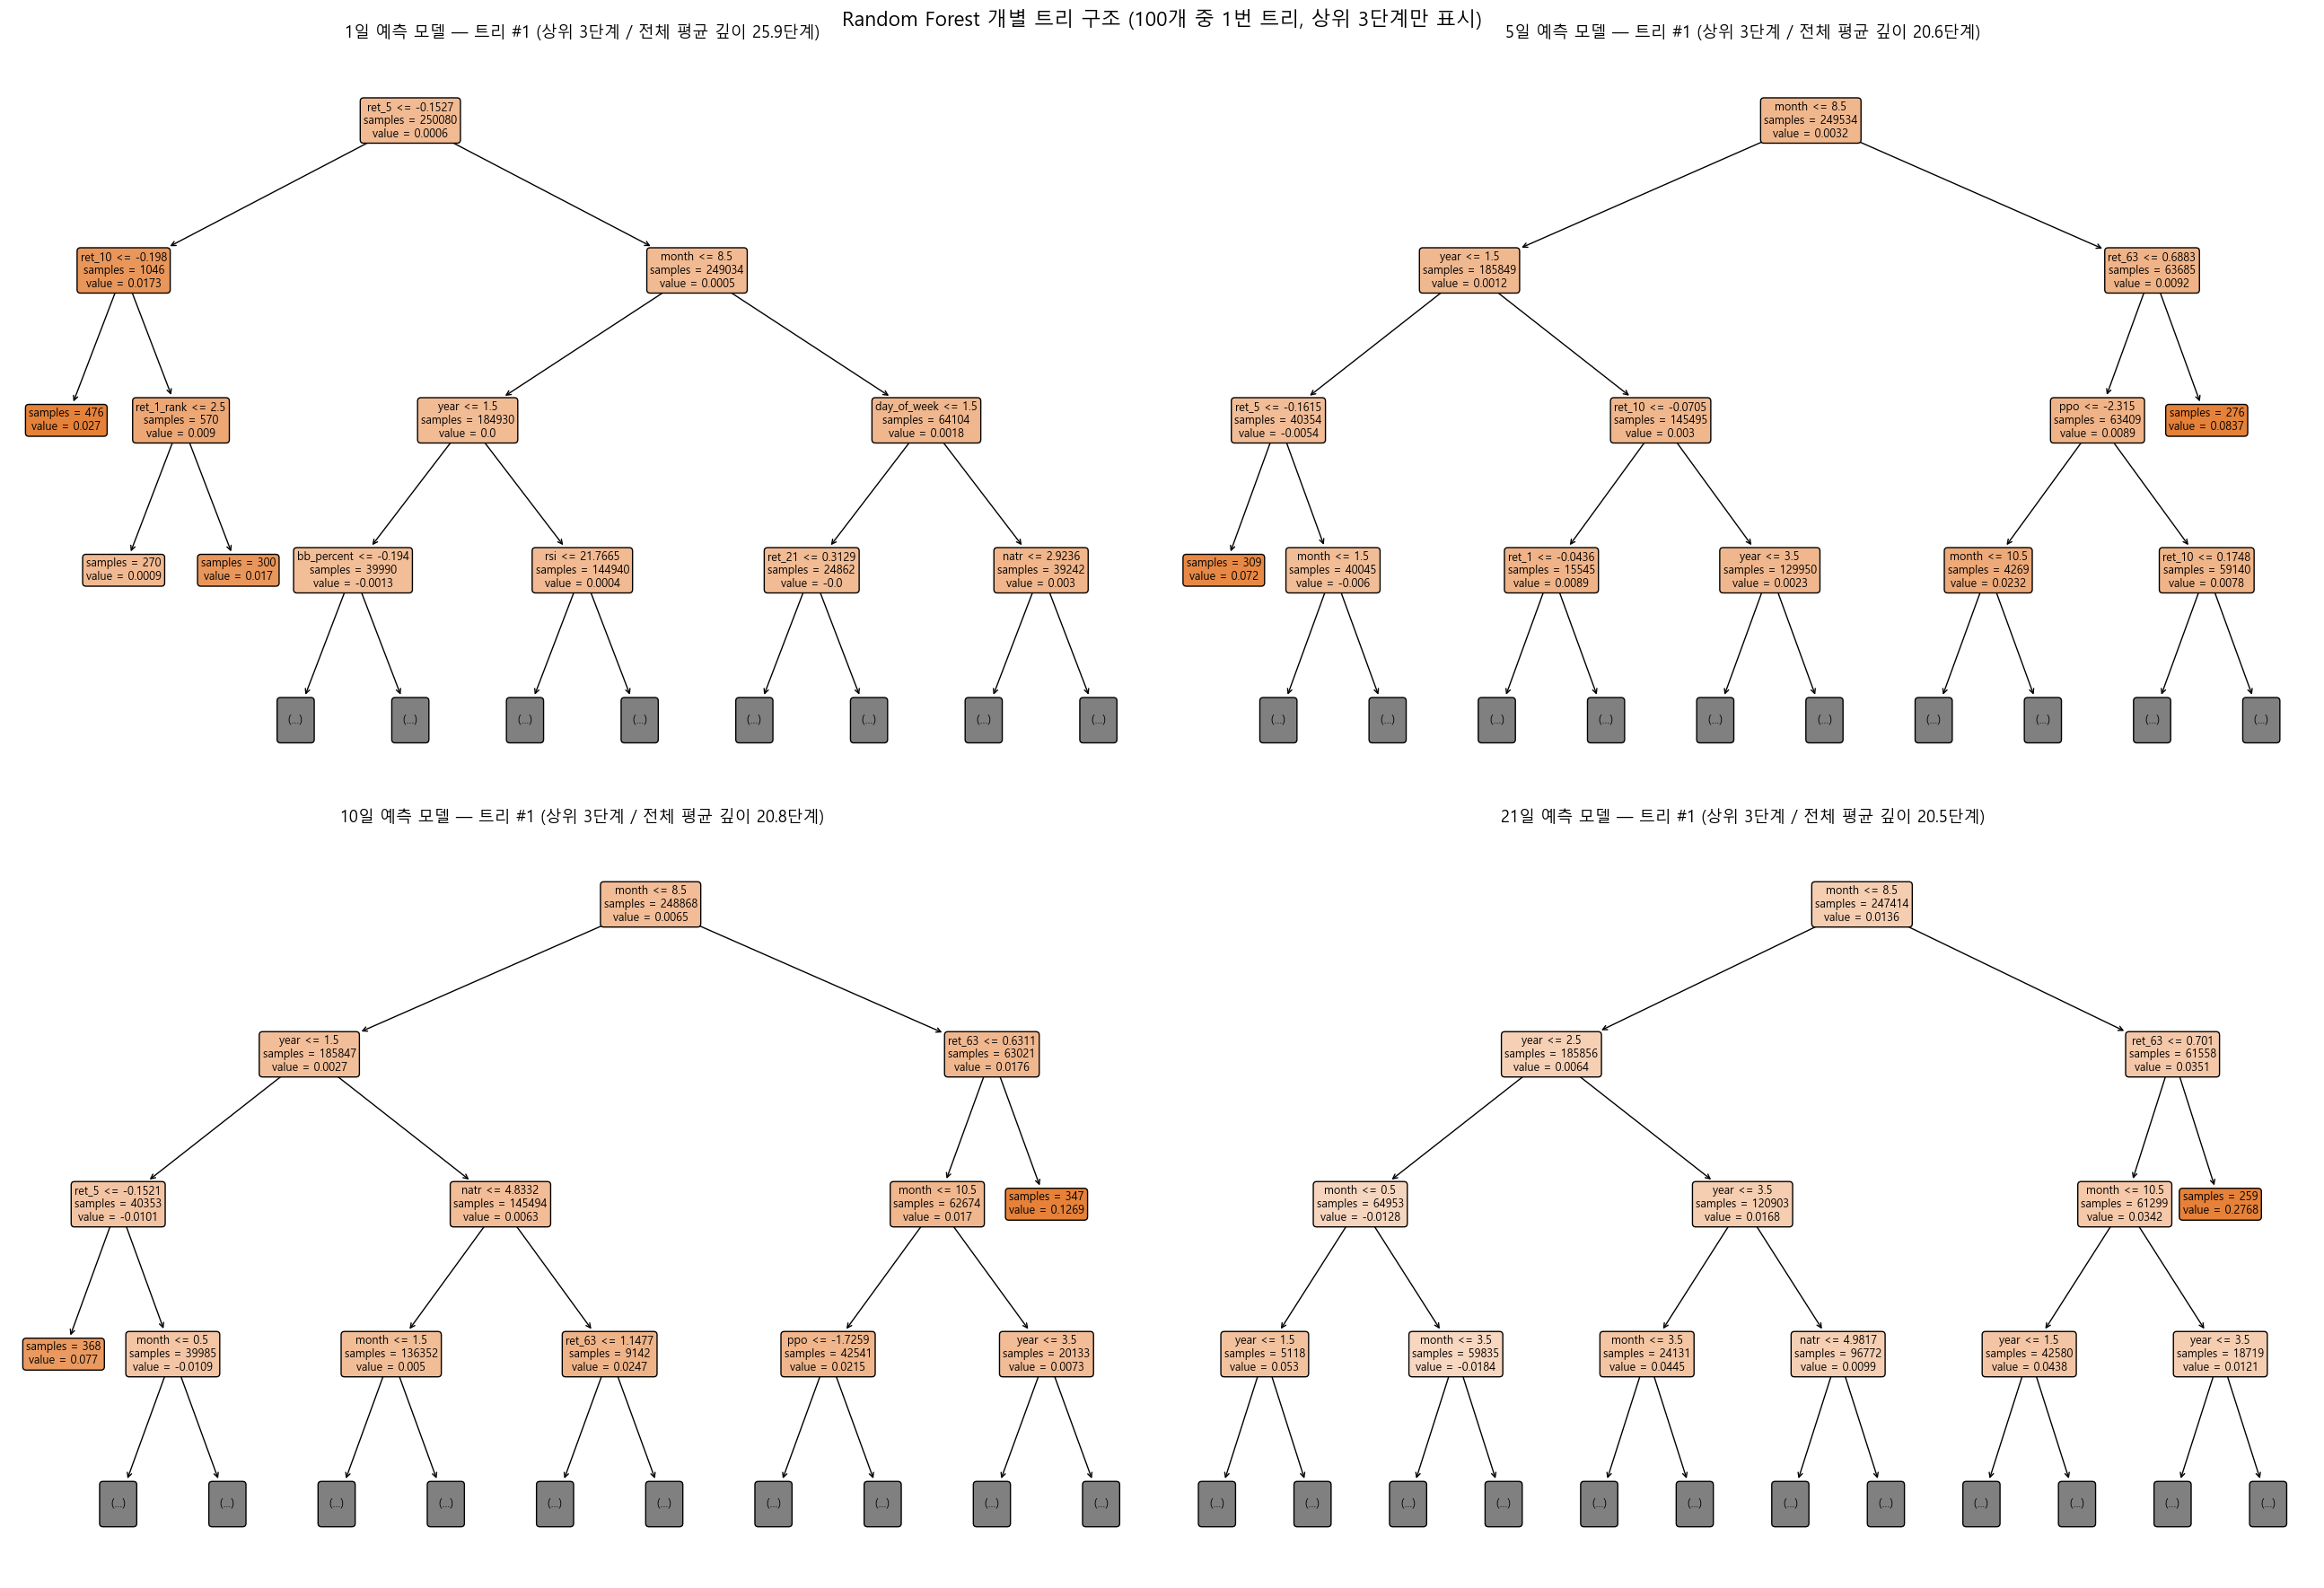

In [21]:
# 3. 모델 트리 구조 시각화 — 각 호라이즌 최종 모델의 첫 번째 트리를 상위 3단계까지 표시
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 한글 폰트 설정 (그래프에서 한글이 깨지는 문제 방지)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(26, 18))
for ax, h in zip(axes.flat, HORIZONS):
    forest_h = models_by_horizon[h]
    tree0 = forest_h.estimators_[0]
    avg_depth = np.mean([est.get_depth() for est in forest_h.estimators_])

    plot_tree(tree0, max_depth=3, feature_names=feature_cols, filled=True,
              rounded=True, fontsize=9, precision=4, impurity=False, ax=ax)
    ax.set_title(f'{h}일 예측 모델 — 트리 #1 (상위 3단계 / 전체 평균 깊이 {avg_depth:.1f}단계)', fontsize=13)

plt.suptitle('Random Forest 개별 트리 구조 (100개 중 1번 트리, 상위 3단계만 표시)', fontsize=16)
plt.tight_layout()

tree_plot_path = OUTPUT_DIR / 'model_tree_plot.png'
fig.savefig(tree_plot_path, dpi=200)
print(f"모델 트리 구조 그래프 저장 위치: {tree_plot_path.resolve()}")
plt.show()

## [4단계] Backtrader 백테스트 — 1/5/10/21일 예측 모델 롱숏(Long-Short) 전략 (vs Nikkei 225)

각 호라이즌 모델의 Out-of-Sample 예측 수익률 상위 `N_SELECT`개 종목은 매수(Long), 하위 `N_SELECT`개 종목은 매도(Short)하여 동일가중으로 배분하는 시장 중립(Market-Neutral) 전략을 매일 리밸런싱합니다.

- 매매 비용: 체결 1회당 고정 **$0.02** (슬리피지 없음)
- 거래일 캘린더: 도쿄증권거래소(XTKS) 실제 거래일
- 벤치마크: 니케이225(^N225) 지수 (야후 파이낸스)
- 결과: 1개의 Figure 안에 2×2 서브플롯(1일/5일/10일/21일)으로 표시

In [22]:
# 4-1. Backtrader 공통 설정 (거래일 캘린더, 니케이225 벤치마크, 커미션/피드/전략 클래스)
import backtrader as bt
import exchange_calendars as xcals

N_SELECT = 10
INITIAL_CASH = 1_000_000
COMMISSION_PER_TRADE = 0.02  # 거래(체결) 1회당 고정 수수료($), 슬리피지 없음

_cal = xcals.get_calendar('XTKS')
_oos_start = min(oos_preds_by_horizon[h]['date'].min() for h in HORIZONS)
_oos_end = max(oos_preds_by_horizon[h]['date'].max() for h in HORIZONS)
bt_sessions = _cal.sessions_in_range(_oos_start, _oos_end)
bt_sessions = pd.DatetimeIndex(bt_sessions.tz_localize(None) if bt_sessions.tz is not None else bt_sessions)
print(f"백테스트 거래일(XTKS): {len(bt_sessions)}일 ({bt_sessions[0].date()} ~ {bt_sessions[-1].date()})")

# 니케이225 벤치마크 (야후 파이낸스)
_nikkei_raw = yf.download('^N225', start=str(bt_sessions[0].date()),
                          end=str((bt_sessions[-1] + pd.Timedelta(days=5)).date()), progress=False)
nikkei_close = _nikkei_raw['Close']
if isinstance(nikkei_close, pd.DataFrame):
    nikkei_close = nikkei_close.iloc[:, 0]
nikkei_close = nikkei_close.reindex(bt_sessions).ffill().bfill()
nikkei_cum_pct = (nikkei_close / nikkei_close.iloc[0] - 1) * 100


class MLSignalData(bt.feeds.PandasData):
    lines = ('predicted',)
    params = (('predicted', -1),)


class FlatTradeCommission(bt.CommInfoBase):
    params = (('commission', COMMISSION_PER_TRADE), ('stocklike', True))

    def _getcommission(self, size, price, pseudoexec):
        return self.p.commission if size != 0 else 0.0


class MLLongShortStrategy(bt.Strategy):
    params = dict(n_select=N_SELECT)

    def next(self):
        signals = {d._name: d.predicted[0] for d in self.datas if not np.isnan(d.predicted[0])}

        if len(signals) < 2 * self.p.n_select:
            for d in self.datas:
                if self.getposition(d).size != 0:
                    self.order_target_percent(d, target=0.0)
            return

        ranked = sorted(signals.items(), key=lambda kv: kv[1], reverse=True)
        weight = 1.0 / self.p.n_select
        targets = {name: weight for name, _ in ranked[:self.p.n_select]}
        targets.update({name: -weight for name, _ in ranked[-self.p.n_select:]})

        by_name = {d._name: d for d in self.datas}
        for name, d in by_name.items():
            tgt = targets.get(name, 0.0)
            if tgt != 0.0 or self.getposition(d).size != 0:
                self.order_target_percent(d, target=tgt)


def run_backtrader_backtest(pred_df, prices_df, sessions, n_select=N_SELECT, initial_cash=INITIAL_CASH):
    pred_series = pred_df.set_index(['date', 'ticker'])['pred'].sort_index()
    tickers = pred_series.index.get_level_values('ticker').unique().tolist()

    cerebro = bt.Cerebro()
    cerebro.broker.setcash(initial_cash)
    cerebro.broker.addcommissioninfo(FlatTradeCommission())

    n_feeds = 0
    for t in tickers:
        try:
            # 인덱스가 (date, ticker) 순서이므로 .loc[t]가 아닌 .xs(t, level='ticker')로 조회
            # (그렇지 않으면 종목코드('1306' 등)가 날짜 레벨과 매칭되어 파싱 에러 발생)
            dft = prices_df.xs(t, level='ticker')[['open', 'high', 'low', 'close', 'vol']].rename(columns={'vol': 'volume'}).copy()
        except KeyError:
            continue
        if dft.empty:
            continue
        dft = dft.reindex(sessions)
        dft[['open', 'high', 'low', 'close']] = dft[['open', 'high', 'low', 'close']].ffill().bfill()
        dft['volume'] = dft['volume'].fillna(0)
        dft['predicted'] = pred_series.xs(t, level='ticker').reindex(sessions)
        if dft['predicted'].notna().sum() == 0:
            continue
        cerebro.adddata(MLSignalData(dataname=dft), name=str(t))
        n_feeds += 1

    cerebro.addstrategy(MLLongShortStrategy, n_select=n_select)
    cerebro.addanalyzer(bt.analyzers.TimeReturn, _name='time_return')
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe', timeframe=bt.TimeFrame.Days, annualize=True, riskfreerate=0.0)
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')

    start_value = cerebro.broker.getvalue()
    run_results = cerebro.run()
    end_value = cerebro.broker.getvalue()
    strat = run_results[0]

    returns = pd.Series(strat.analyzers.time_return.get_analysis()).sort_index()
    returns.index = pd.to_datetime(returns.index)
    sharpe = strat.analyzers.sharpe.get_analysis().get('sharperatio')
    maxdd = strat.analyzers.drawdown.get_analysis().max.drawdown

    return {'n_feeds': n_feeds, 'start_value': start_value, 'end_value': end_value,
            'returns': returns, 'sharpe': sharpe, 'maxdd': maxdd}

백테스트 거래일(XTKS): 465일 (2018-01-04 ~ 2019-11-29)


In [23]:
# 4-2. 호라이즌별 Backtrader 백테스트 실행
bt_results_by_horizon = {}
for h in HORIZONS:
    print(f"--- Backtrader 백테스트: {h}일 예측 모델 ---")
    res = run_backtrader_backtest(oos_preds_by_horizon[h], prices, bt_sessions)
    bt_results_by_horizon[h] = res
    total_ret = (res['end_value'] / res['start_value'] - 1) * 100
    sharpe_txt = f"{res['sharpe']:.4f}" if res['sharpe'] is not None else "N/A"
    print(f"  종목 피드 수: {res['n_feeds']}, 총수익률: {total_ret:.2f}%, Sharpe: {sharpe_txt}, MDD: {res['maxdd']:.2f}%")

bt_returns_df = pd.concat({h: bt_results_by_horizon[h]['returns'] for h in HORIZONS}, axis=1)
bt_returns_df.columns = [f'{h}d' for h in HORIZONS]
bt_returns_df.to_csv(OUTPUT_DIR / 'backtrader_daily_returns_all_horizons.csv')
print(f"\nBacktrader 일별 수익률 저장 위치: {(OUTPUT_DIR / 'backtrader_daily_returns_all_horizons.csv').resolve()}")

--- Backtrader 백테스트: 1일 예측 모델 ---
  종목 피드 수: 250, 총수익률: -40.81%, Sharpe: -1.5161, MDD: 43.54%
--- Backtrader 백테스트: 5일 예측 모델 ---
  종목 피드 수: 250, 총수익률: -14.94%, Sharpe: -0.3423, MDD: 26.70%
--- Backtrader 백테스트: 10일 예측 모델 ---
  종목 피드 수: 250, 총수익률: 14.76%, Sharpe: 0.4699, MDD: 25.35%
--- Backtrader 백테스트: 21일 예측 모델 ---
  종목 피드 수: 250, 총수익률: 44.38%, Sharpe: 1.0569, MDD: 15.10%

Backtrader 일별 수익률 저장 위치: G:\내 드라이브\03.졸업논문\ml4t_pipeline\model\11단원\backtrader_daily_returns_all_horizons.csv


Backtrader 결과 그래프(2x2) 저장 위치: G:\내 드라이브\03.졸업논문\ml4t_pipeline\model\11단원\backtrader_all_horizons_plot.png


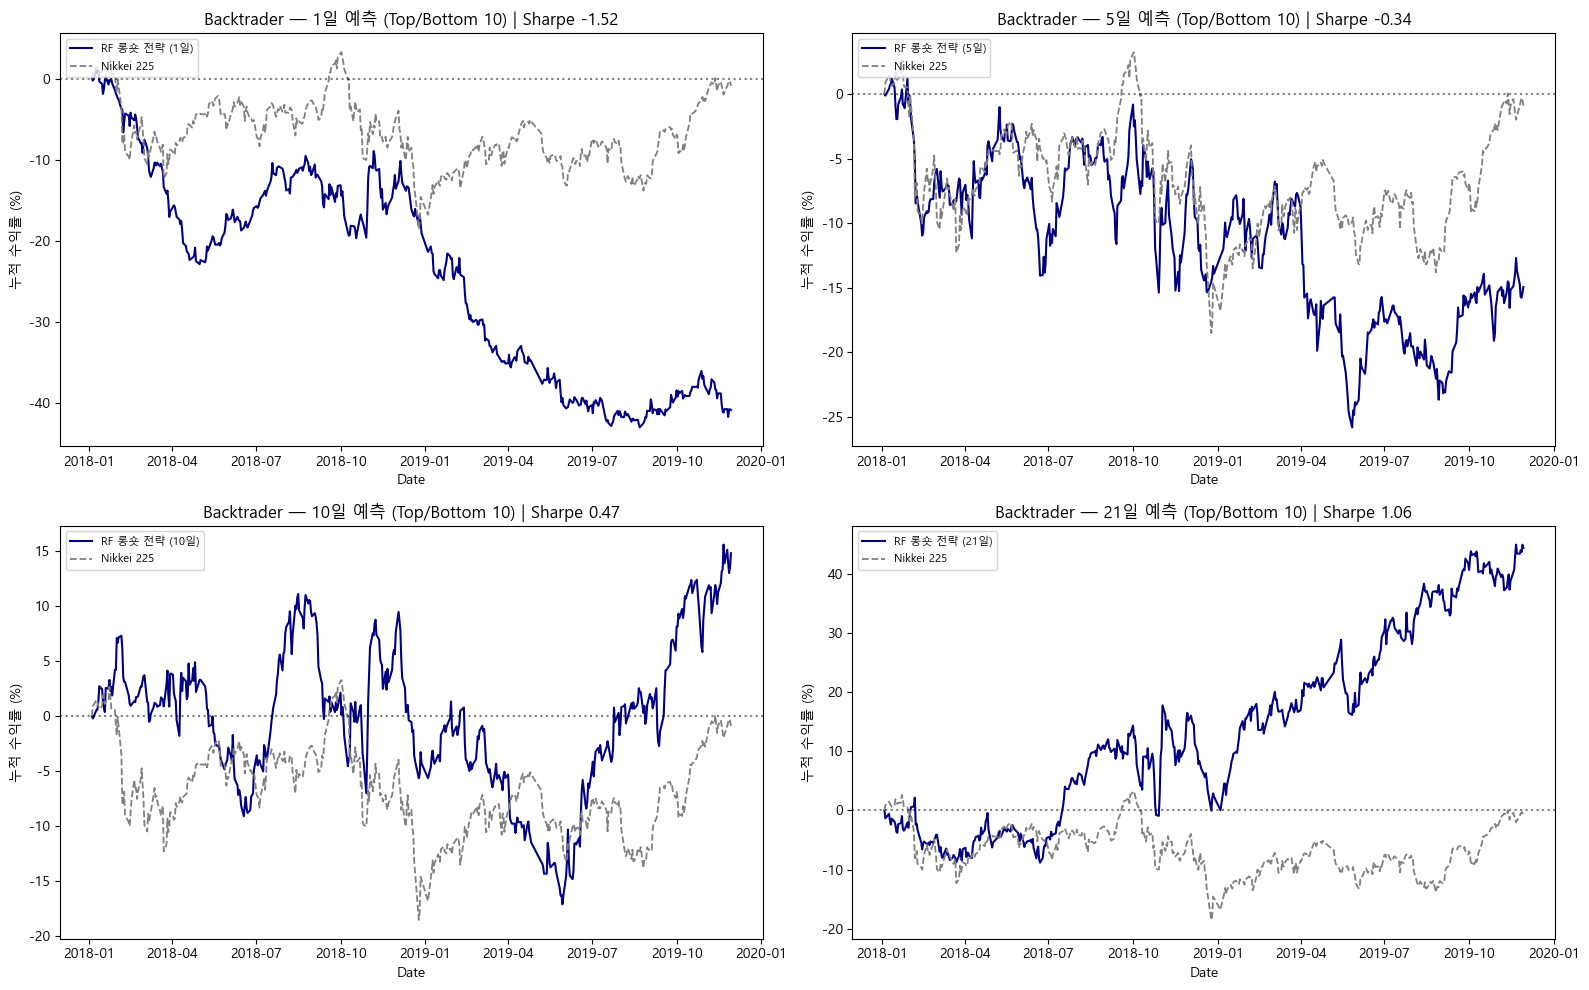

In [24]:
# 4-3. Backtrader 결과 시각화 (2x2, 호라이즌별 vs 니케이225)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, h in zip(axes, HORIZONS):
    ret = bt_results_by_horizon[h]['returns']
    cum_pct = ((1 + ret).cumprod() - 1) * 100
    nk = nikkei_cum_pct.reindex(cum_pct.index).ffill()

    ax.plot(cum_pct.index, cum_pct.values, color='navy', lw=1.5, label=f'RF 롱숏 전략 ({h}일)')
    ax.plot(nk.index, nk.values, color='gray', lw=1.3, linestyle='--', label='Nikkei 225')
    ax.axhline(0, color='black', linestyle=':', alpha=0.5)

    sharpe_h = bt_results_by_horizon[h]['sharpe']
    sharpe_txt = f"{sharpe_h:.2f}" if sharpe_h is not None else "N/A"
    ax.set_title(f'Backtrader — {h}일 예측 (Top/Bottom {N_SELECT}) | Sharpe {sharpe_txt}')
    ax.set_ylabel('누적 수익률 (%)')
    ax.set_xlabel('Date')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
bt_plot_path = OUTPUT_DIR / 'backtrader_all_horizons_plot.png'
fig.savefig(bt_plot_path, dpi=300)
print(f"Backtrader 결과 그래프(2x2) 저장 위치: {bt_plot_path.resolve()}")
plt.show()

## [5단계] Zipline 백테스트 — 1/5/10/21일 예측 모델 롱숏 전략 (vs Nikkei 225)

Backtrader와 동일한 예측 신호, 동일한 롱숏 규칙(상/하위 `N_SELECT`개 종목, 동일가중, 매일 리밸런싱), 동일한 매매 비용(체결 1회당 고정 $0.02, 슬리피지 없음), 동일한 XTKS 거래일 캘린더를 사용해 **Zipline** 엔진으로도 백테스트합니다. 가격 데이터(CSV 번들)는 한 번만 적재(ingest)하고, 예측 신호만 호라이즌별로 교체하여 4회 실행합니다.

**Backtrader와 체결 타이밍 정렬**: Backtrader는 신호가 발생한 다음 거래일 시가에 체결되는 반면, Zipline은 `time_rules.market_open()` 설정상 신호가 발생한 당일 시가에 바로 체결됩니다. 이 하루 차이 자체가 두 엔진의 성과 차이를 만드는 주된 원인이 되는 것을 막기 위해, Zipline에 넘기는 예측 신호를 `.shift(1)`로 하루 뒤로 밀어 Backtrader와 동일한 "T일 신호 → T+1일 시가 체결" 타이밍으로 맞춥니다.

In [25]:
# 5-1. Zipline CSV 번들 구축 및 적재 (XTKS 캘린더, 4개 호라이즌 공통 가격 데이터)
import os
import shutil

ZIPLINE_ROOT = (OUTPUT_DIR / '.zipline_root').resolve()
os.environ['ZIPLINE_ROOT'] = str(ZIPLINE_ROOT)

from zipline.data.bundles import register, ingest
from zipline.data.bundles.csvdir import csvdir_equities

BUNDLE_NAME = 'ml4t_japan_rf_bundle'
csv_root = (OUTPUT_DIR / '_zipline_csv_bundle').resolve()
csv_dir = csv_root / 'daily'
if csv_root.exists():
    shutil.rmtree(csv_root)
csv_dir.mkdir(parents=True, exist_ok=True)

all_pred_tickers = sorted(set().union(*[set(oos_preds_by_horizon[h]['ticker'].unique()) for h in HORIZONS]))

n_csv = 0
for t in all_pred_tickers:
    try:
        # 인덱스가 (date, ticker) 순서이므로 .loc[t]가 아닌 .xs(t, level='ticker')로 조회
        dft = prices.xs(t, level='ticker')[['open', 'high', 'low', 'close', 'vol']].rename(columns={'vol': 'volume'}).copy()
    except KeyError:
        continue
    if dft.empty:
        continue
    dft = dft.reindex(bt_sessions)
    dft[['open', 'high', 'low', 'close']] = dft[['open', 'high', 'low', 'close']].ffill().bfill()
    dft['volume'] = dft['volume'].fillna(0)
    dft.index.name = 'date'
    dft['dividend'] = 0.0
    dft['split'] = 1.0
    dft = dft[['open', 'high', 'low', 'close', 'volume', 'dividend', 'split']].sort_index()
    dft.to_csv(csv_dir / f'{t}.csv')
    n_csv += 1

print(f"Zipline CSV 번들 생성 완료: {n_csv}개 종목, {len(bt_sessions)}개 세션 (XTKS)")

register(
    BUNDLE_NAME,
    csvdir_equities(['daily'], str(csv_root)),
    calendar_name='XTKS',
    start_session=bt_sessions[0],
    end_session=bt_sessions[-1],
)
ingest(BUNDLE_NAME, show_progress=True)
print("Zipline 번들 적재(ingest) 완료")

Zipline CSV 번들 생성 완료: 250개 종목, 465개 세션 (XTKS)
Merging daily equity files:
Loading custom pricing data: 
Zipline 번들 적재(ingest) 완료


In [26]:
# 5-2. 호라이즌별 Zipline 백테스트 실행
from zipline.api import (
    order_target_percent, schedule_function, date_rules, time_rules,
    set_commission, set_slippage, record, symbol, get_datetime
)
from zipline.finance import commission as zp_commission, slippage as zp_slippage
from zipline import run_algorithm


def make_zipline_initialize(pred_by_date, n_select=N_SELECT):
    def initialize(context):
        context.n_select = n_select
        context.pred_by_date = pred_by_date
        context.asset_map = {}
        for t in pred_by_date.columns:
            try:
                context.asset_map[t] = symbol(str(t))
            except Exception:
                pass
        set_commission(zp_commission.PerTrade(cost=COMMISSION_PER_TRADE))  # 체결 1회당 고정 $0.02
        set_slippage(zp_slippage.FixedSlippage(spread=0.0))                # 슬리피지 없음
        schedule_function(rebalance, date_rules.every_day(), time_rules.market_open())
        schedule_function(record_vars, date_rules.every_day(), time_rules.market_close())
    return initialize


def rebalance(context, data):
    dt = pd.Timestamp(get_datetime().date())
    if dt not in context.pred_by_date.index:
        return
    today = context.pred_by_date.loc[dt].dropna()
    if len(today) < 2 * context.n_select:
        return

    ranked = today.sort_values(ascending=False)
    weight = 1.0 / context.n_select

    target_assets = {}
    for t in ranked.index[:context.n_select]:
        a = context.asset_map.get(t)
        if a is not None and data.can_trade(a):
            target_assets[a] = weight
    for t in ranked.index[-context.n_select:]:
        a = context.asset_map.get(t)
        if a is not None and data.can_trade(a):
            target_assets[a] = -weight

    for a in list(context.portfolio.positions.keys()):
        if a not in target_assets:
            order_target_percent(a, 0.0)
    for a, w in target_assets.items():
        order_target_percent(a, w)


def record_vars(context, data):
    record(portfolio_value=context.portfolio.portfolio_value)


zp_results_by_horizon = {}
for h in HORIZONS:
    print(f"--- Zipline 백테스트: {h}일 예측 모델 ---")
    # Backtrader(다음날 시가 체결)와 타이밍을 맞추기 위해 신호를 1거래일 뒤로 shift
    pred_by_date_h = oos_preds_by_horizon[h].set_index(['date', 'ticker'])['pred'].unstack('ticker').shift(1)

    zp_perf = run_algorithm(
        start=bt_sessions[0],
        end=bt_sessions[-1],
        initialize=make_zipline_initialize(pred_by_date_h),
        capital_base=INITIAL_CASH,
        data_frequency='daily',
        bundle=BUNDLE_NAME,
    )

    zp_returns = zp_perf['returns']
    zp_sharpe = np.sqrt(252) * zp_returns.mean() / zp_returns.std()
    zp_cum = (1 + zp_returns).cumprod()
    zp_mdd = (zp_cum / zp_cum.cummax() - 1).min()

    zp_results_by_horizon[h] = {'perf': zp_perf, 'returns': zp_returns, 'sharpe': zp_sharpe, 'mdd': zp_mdd}
    total_ret = (zp_perf['portfolio_value'].iloc[-1] / INITIAL_CASH - 1) * 100
    print(f"  최종자산: {zp_perf['portfolio_value'].iloc[-1]:,.0f}, 총수익률: {total_ret:.2f}%, Sharpe: {zp_sharpe:.4f}, MDD: {zp_mdd * 100:.2f}%")

zp_returns_df = pd.concat({h: zp_results_by_horizon[h]['returns'] for h in HORIZONS}, axis=1)
zp_returns_df.columns = [f'{h}d' for h in HORIZONS]
zp_returns_df.to_csv(OUTPUT_DIR / 'zipline_daily_returns_all_horizons.csv')
print(f"\nZipline 일별 수익률 저장 위치: {(OUTPUT_DIR / 'zipline_daily_returns_all_horizons.csv').resolve()}")

--- Zipline 백테스트: 1일 예측 모델 ---
  최종자산: 1,096,737, 총수익률: 9.67%, Sharpe: 0.3723, MDD: -14.64%
--- Zipline 백테스트: 5일 예측 모델 ---
  최종자산: 623,980, 총수익률: -37.60%, Sharpe: -1.1380, MDD: -42.14%
--- Zipline 백테스트: 10일 예측 모델 ---
  최종자산: 928,389, 총수익률: -7.16%, Sharpe: -0.1044, MDD: -23.03%
--- Zipline 백테스트: 21일 예측 모델 ---
  최종자산: 897,047, 총수익률: -10.30%, Sharpe: -0.1888, MDD: -24.82%

Zipline 일별 수익률 저장 위치: G:\내 드라이브\03.졸업논문\ml4t_pipeline\model\11단원\zipline_daily_returns_all_horizons.csv


Zipline 결과 그래프(2x2) 저장 위치: G:\내 드라이브\03.졸업논문\ml4t_pipeline\model\11단원\zipline_all_horizons_plot.png


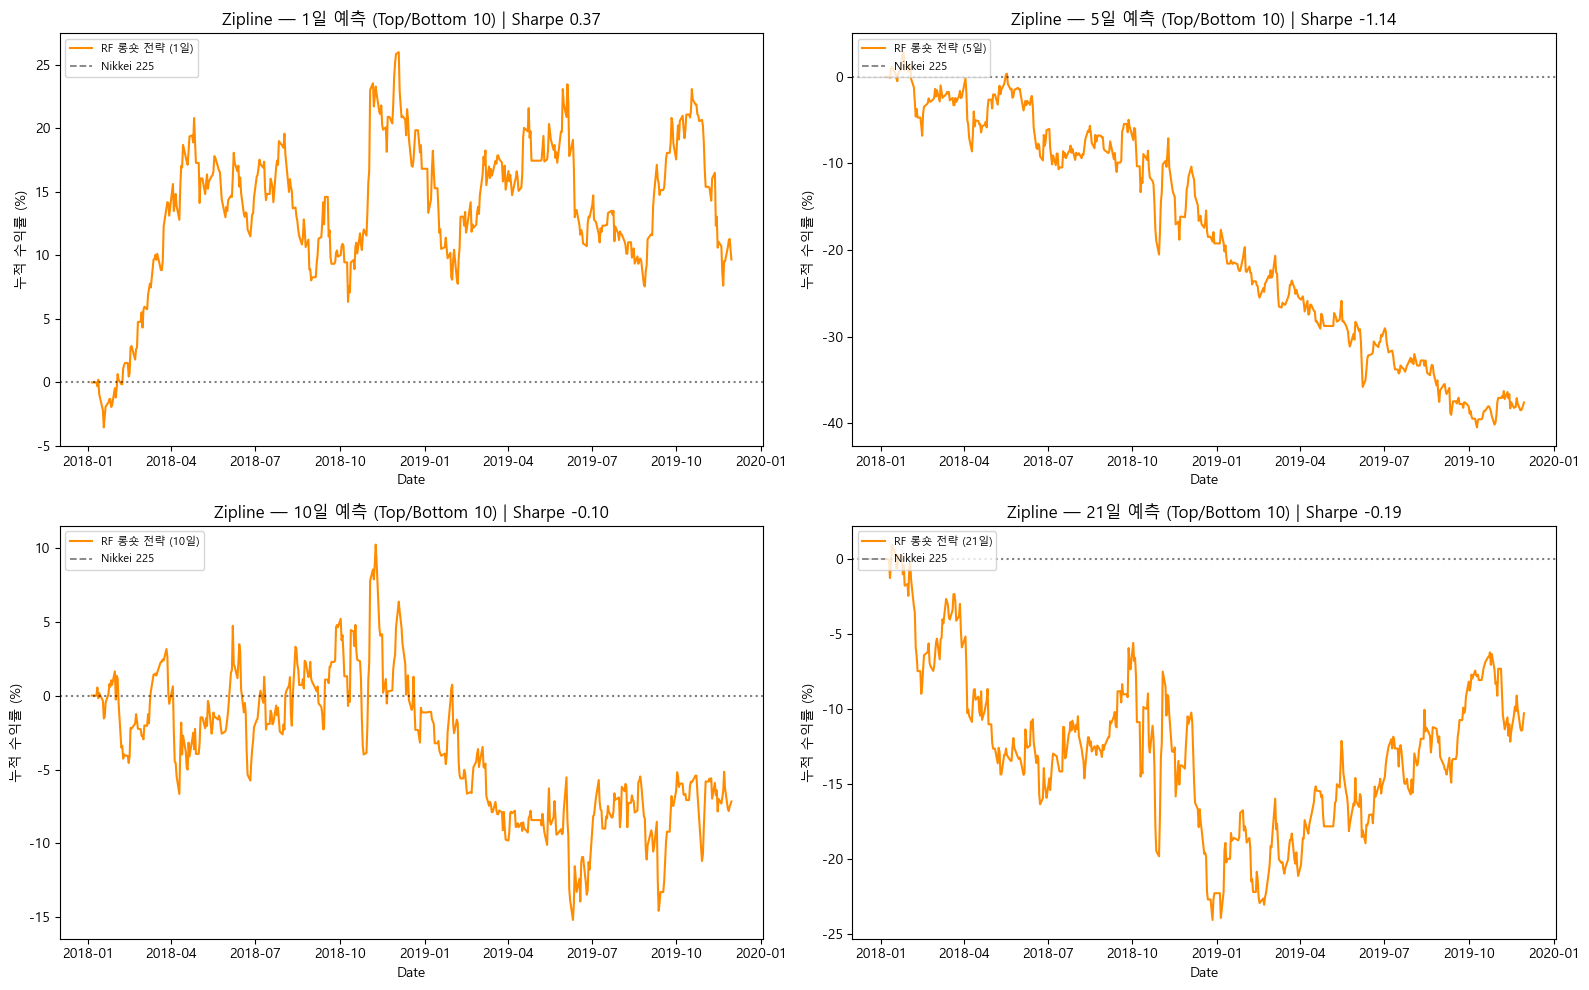

In [27]:
# 5-3. Zipline 결과 시각화 (2x2, 호라이즌별 vs 니케이225)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, h in zip(axes, HORIZONS):
    zp_cum = (1 + zp_results_by_horizon[h]['returns']).cumprod()
    cum_pct = (zp_cum - 1) * 100
    nk = nikkei_cum_pct.reindex(cum_pct.index).ffill()

    ax.plot(cum_pct.index, cum_pct.values, color='darkorange', lw=1.5, label=f'RF 롱숏 전략 ({h}일)')
    ax.plot(nk.index, nk.values, color='gray', lw=1.3, linestyle='--', label='Nikkei 225')
    ax.axhline(0, color='black', linestyle=':', alpha=0.5)

    ax.set_title(f'Zipline — {h}일 예측 (Top/Bottom {N_SELECT}) | Sharpe {zp_results_by_horizon[h]["sharpe"]:.2f}')
    ax.set_ylabel('누적 수익률 (%)')
    ax.set_xlabel('Date')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
zp_plot_path = OUTPUT_DIR / 'zipline_all_horizons_plot.png'
fig.savefig(zp_plot_path, dpi=300)
print(f"Zipline 결과 그래프(2x2) 저장 위치: {zp_plot_path.resolve()}")
plt.show()

In [28]:
# 6. Backtrader vs Zipline 호라이즌별 최종 성과 요약
summary_rows = []
for h in HORIZONS:
    bt_res = bt_results_by_horizon[h]
    zp_res = zp_results_by_horizon[h]
    summary_rows.append({
        '호라이즌': f'{h}일',
        'BT 총수익률(%)': (bt_res['end_value'] / bt_res['start_value'] - 1) * 100,
        'BT Sharpe': bt_res['sharpe'],
        'BT MDD(%)': bt_res['maxdd'],
        'ZP 총수익률(%)': (zp_res['perf']['portfolio_value'].iloc[-1] / INITIAL_CASH - 1) * 100,
        'ZP Sharpe': zp_res['sharpe'],
        'ZP MDD(%)': zp_res['mdd'] * 100,
    })

final_summary = pd.DataFrame(summary_rows).set_index('호라이즌')
display(final_summary.round(4))
final_summary.to_csv(OUTPUT_DIR / 'engine_comparison_summary.csv')

,BT 총수익률(%),BT Sharpe,BT MDD(%),ZP 총수익률(%),ZP Sharpe,ZP MDD(%)
호라이즌,,,,,,
1일,-40.8134,-1.5161,43.5370,9.6737,0.3723,-14.6415
5일,-14.9410,-0.3423,26.7036,-37.6020,-1.1380,-42.1423
10일,14.7598,0.4699,25.3452,-7.1611,-0.1044,-23.0289
21일,44.3803,1.0569,15.0994,-10.2953,-0.1888,-24.8214
